# Example: Simulating a Portfolio with Multiple Asset Geometric Brownian Motion
Suppose we choose a portfolio at the start of 2025 and hold its shares through the year. How much might its wealth vary, and how likely is it to exceed a target return after accounting for a benchmark growth rate? The multiple asset geometric Brownian motion (MAGBM) model from L5b lets us explore these questions by simulating correlated share prices.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Estimate and simulate a multiple asset GBM model:__ Estimate mean growth rates and their covariance from training data, construct the model, and check that simulated growth rates reproduce these estimates.
> * __Compute buy-and-hold portfolio wealth:__ Convert an initial allocation into share counts, calculate wealth on each simulated path, and interpret pointwise prediction bands alongside the observed portfolio wealth and an index fund.
> * __Evaluate portfolio outcomes with the trade rule:__ Compute scaled net present value at the sale time and estimate the probability of exceeding a target, together with its Monte Carlo standard error.

In this example, we estimate the model using 2014 to 2024 data and simulate price paths from the first trading day of 2025. We use a long-only minimum-variance allocation as our default, then compare simulated buy-and-hold wealth with the observed 2025 path and an investment in SPY, an index fund that tracks the S&P 500. Finally, we apply the L4b trade rule to the portfolio's terminal wealth.

Let's get started!

___


## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file. It activates the course project, defines local paths, loads the required packages, and includes the helper code in [src/Compute.jl](src/Compute.jl).

Let's set up our code environment:

In [1]:
# Activate the course environment, load packages, and include the local helpers -
# @__DIR__ is the kernel's working folder, normally this notebook's folder.
include(joinpath(@__DIR__, "Include.jl"));

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
We use daily market data for firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500), together with several exchange-traded funds and volatility products. The data include open, high, low, and close prices, as well as the volume-weighted average prices used in our calculations.

We separate the data into two periods:

> __Training and testing data:__
>
> * __Training, January 3, 2014 to December 31, 2024:__ We use these observations to estimate the model's mean growth rates and covariance, and to choose the minimum-variance allocation.
> * __Testing, January 2, 2025 to December 31, 2025:__ We use the first day's prices to initialize the simulation and buy the shares. The subsequent prices give the observed wealth path for comparison with the simulations.

Some firms have shorter records, so we first keep the series with the same number of trading days as AAPL. We will check matching trading dates for the selected firms before constructing the growth-rate matrix.

Let's load the training data with [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), apply this screen, and store the retained series in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # Load the training data and use AAPL's record length as the reference -
    # |> passes the loaded bundle to the anonymous function x-> x["dataset"].
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # ticker => DataFrame
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has a complete record
    dataset = Dict{String, DataFrame}(); # empty dictionary for the retained series

    # Keep the series with the full number of trading days -
    # Equal lengths do not guarantee equal dates, so Task 1 also checks the dates.
    for (ticker, data) ∈ original_dataset # each Dict entry unpacks into its key and value
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # a let block returns its last expression, and its other variables stay private
end;

Next, we load the testing data with [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), apply the same screen, and store the retained 2025 series in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # Load the 2025 testing data and apply the same record-length screen -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # default year = 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL trading days in 2025
    dataset = Dict{String, DataFrame}(); # local name, separate from the training dataset

    # Keep the series with the full number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # returned and stored as dataset_2025
end;

### Constants
We measure time in years and use $\Delta t=1/252$ for one trading-day step. We also set the initial wealth $W_0$ and the number of simulated paths below.

For the trade rule, we assume a constant, continuously compounded benchmark growth rate $g_y$. We use $g_y=0.041$ per year as a rounded benchmark assumption based on the [4.16% one-year Treasury par yield reported for December 31, 2024](https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?field_tdr_date_value_month=202412&type=daily_treasury_yield_curve). The default target $\rho_\star=0$ asks whether the portfolio exceeds this benchmark at the sale time.

The `allocation_case` setting chooses how we divide the initial wealth among the firms:

* __`:GMV`:__ Use the long-only global minimum-variance weights computed from the training data. This is our default allocation.
* __`:equal`:__ Assign the same initial weight to every firm.
* __`:single`:__ Invest all the initial wealth in NVDA.
* __`:dirichlet`:__ Draw one random allocation from the Dirichlet distribution introduced in L5b.

The fixed random seed makes the calculation reproducible when we rerun from this cell. Let's set these values:

In [4]:
# Set the time step, budget, simulation size, and trade-rule inputs -
Δt = (1.0/252.0); # time step (one trading day, in years)
W₀ = 1000.0; # initial wealth (USD)
number_of_paths = 2000; # number of simulated price paths
g_y = 0.041; # benchmark growth rate, continuously compounded (1/yr)
ρ_target = 0.0; # target scaled NPV ρ⋆ (dimensionless), 0 asks whether we beat the benchmark
Random.seed!(5660); # fixes the random draws when the cells below run in order
allocation_case = :GMV; # a Symbol label: :GMV, :equal, :single, or :dirichlet

___

## Task 1: Estimate the Model and Simulate Correlated Price Paths
In this task, we estimate the model from the training data, simulate share prices through 2025, and check that the simulated growth rates agree with the estimated means and covariance.

We use the same thirteen firms as the [minimum-variance portfolio example](CHEME-5660-L6a-Example-Data-MinVar-Portfolio-Fall-2026.ipynb), so we can simulate its minimum-variance allocation. Their order in `my_list_of_tickers::Vector{String}` sets the firm order in every vector and matrix that follows:

In [5]:
# Choose the firms, in the order used by every vector and matrix below -
my_list_of_tickers = [
    "AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", # technology and semiconductors
    "GS", "BAC", "WFC", "C", "F", "GM", "JNJ" # banks, automakers, and health care
]; # M = 13 firms

### Estimate mean growth rates and covariance
For firm $i$ over the interval from $t_{j-1}$ to $t_j$, the growth rate is given by:
$$
g_j^{(i)}=\frac{1}{\Delta t}\ln\!\left(\frac{S_i(t_j)}{S_i(t_{j-1})}\right).
$$
[The log_growth_matrix(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix) computes these growth rates and stores them in the matrix $\mathbf{G}$, with one row per price change and one column per firm. First, we check that the selected firms share the same trading dates, so each row compares the same interval.

We use [the mean(...) function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.mean) to average each column of $\mathbf{G}$. The sample means $\mathbf{g}^{\prime}$ estimate the model's mean growth rates $\mu_{g,i}$, and [the cov(...) function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov) gives the growth-rate covariance $\hat{\mathbf{\Sigma}}_g$. The price model uses the covariance rate from L5b, which is the growth-rate covariance scaled by the time step:
$$
\hat{\mathbf C}=\Delta t\,\hat{\mathbf\Sigma}_g.
$$
Let's compute these estimates. We store $\mathbf{g}^{\prime}$ in `ĝ::Vector{Float64}`, $\hat{\mathbf{\Sigma}}_g$ in `Σ̂_g::Matrix{Float64}`, and $\hat{\mathbf{C}}$ in `Ĉ::Matrix{Float64}`:

In [6]:
ĝ, Σ̂_g, Ĉ = let

    # Check that each firm has the same trading dates as AAPL in both periods -
    # @assert stops the cell with an error if its condition is false.
    for ticker ∈ my_list_of_tickers
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp # training dates
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp # testing dates
    end

    # Compute the growth-rate matrix G from the training prices only -
    # N training days give N - 1 rows. Row j covers day j to day j + 1, and column i is firm i.
    # Δt = Δt is a keyword argument. risk_free_rate keeps its default of 0.0.
    G = log_growth_matrix(dataset, my_list_of_tickers, Δt = Δt); # (N - 1) × M matrix (1/yr)

    # Estimate g′, Σ̂_g, and the covariance rate Ĉ = Δt Σ̂_g -
    # dims=1 works down each column, giving one value per firm.
    ĝ = mean(G, dims=1) |> vec; # vec turns the 1 × M row into an M-vector, g′ (1/yr)
    Σ̂_g = cov(G, dims=1); # M × M sample covariance, divides by rows - 1 (1/yr²)
    Ĉ = Δt*Σ̂_g; # covariance rate (1/yr)
    (ĝ, Σ̂_g, Ĉ); # the returned tuple unpacks into the three names on the first line
end;

### Examine the estimates
Let's look at the estimated growth and variability of each firm. The table reports each firm's sample mean growth rate $g_i^{\prime}$ (`g_mean`) and growth-rate standard deviation $\sigma_{g,i}=\sqrt{\hat{\Sigma}_{g,ii}}$ (`σ_g`), both in inverse years. It also reports the __volatility__ $\hat{\sigma}_i$ (`σ̂`) used in the price model, in inverse square-root years. Since $\hat{\mathbf C}=\Delta t\,\hat{\mathbf\Sigma}_g$, the volatility is given by:
$$
\hat{\sigma}_i=\sqrt{\hat C_{ii}}=\sqrt{\Delta t}\,\sigma_{g,i}.
$$
We display these estimates with [the pretty_table(...) function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table):

In [7]:
let

    # Compute each firm's growth-rate standard deviation -
    σ_g = sqrt.(diag(Σ̂_g)); # diag takes the variances, sqrt. is an element-wise root (1/yr)

    # Build the table, one row per firm -
    # round. changes only the displayed values. The model keeps full precision.
    df = DataFrame(
        ticker = my_list_of_tickers,
        g_mean = round.(ĝ, digits=4), # g′ᵢ (1/yr)
        σ_g = round.(σ_g, digits=3), # σ_g,i (1/yr)
        σ̂ = round.(sqrt.(diag(Ĉ)), digits=4) # σ̂ᵢ = sqrt(Ĉᵢᵢ) = sqrt(Δt) σ_g,i (1/√yr)
    );

    # Display the table -
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- ---------
  ticker    g_mean       σ_g         σ̂ 
  String   Float64   Float64   Float64 
 -------- --------- --------- ---------
    AAPL    0.2328     3.723    0.2345
    MSFT    0.2222     3.421    0.2155
    INTC   -0.0228     4.672    0.2943
      MU    0.1266     6.454    0.4066
     AMD     0.312     7.529    0.4743
    NVDA    0.5324     6.169    0.3886
      GS    0.1064     3.898    0.2456
     BAC    0.0897     4.266    0.2687
     WFC      0.04     4.211    0.2653
       C    0.0258     4.518    0.2846
       F   -0.0407     5.101    0.3213
      GM    0.0268     5.102    0.3214
     JNJ     0.041     2.441    0.1537
 -------- --------- --------- ---------


For the default ticker list, AMD has the largest estimated volatility and JNJ the smallest. To simulate a portfolio, we also need to know how the firms' growth rates move together.

The heatmap below shows the correlation between each pair of firms' growth rates, which is their covariance divided by the product of their standard deviations. A correlation near $1$ means the growth rates tend to rise and fall together, while a value near $0$ indicates a weak linear relationship. Let's display these correlations with [the heatmap(...) function](https://docs.juliaplots.org/stable/api/#Plots.heatmap-Tuple):

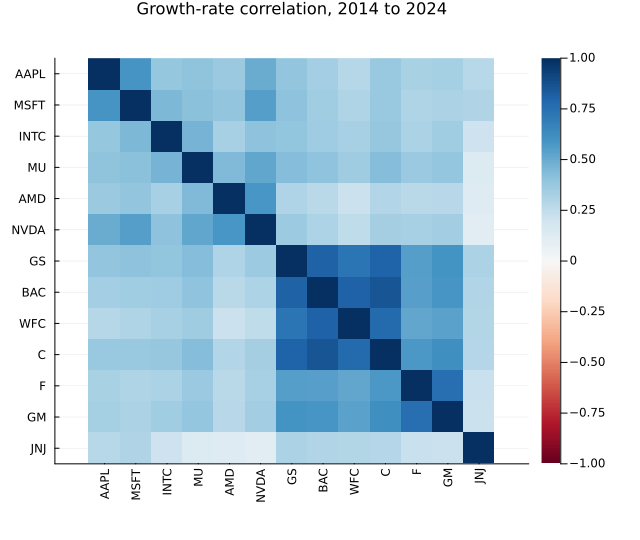

In [8]:
let

    # Convert the covariance to correlation, ρ̂ᵢⱼ = Σ̂_g,ij / (σ_g,i σ_g,j) -
    σ_g = sqrt.(diag(Σ̂_g)); # growth-rate standard deviations (1/yr)
    ρ̂ = Σ̂_g ./ (σ_g*σ_g'); # column times row is the M × M outer product, ./ divides entrywise
    M = length(my_list_of_tickers); # number of firms

    # Plot the correlation matrix -
    # clims = (-1, 1) fixes the color scale, and yflip = true puts the first ticker in the top row.
    heatmap(ρ̂,
        xticks = (1:M, my_list_of_tickers), yticks = (1:M, my_list_of_tickers),
        xrotation = 90, color = :RdBu, clims = (-1, 1),
        colorbar_ticks = (-1:0.5:1), aspect_ratio = :equal, yflip = true,
        title = "Growth-rate correlation, 2014 to 2024", titlefontsize = 11,
        right_margin = 10Plots.mm, size = (640, 540))
end

__What do we see?__ The banks form a dark-blue block of strong positive correlations, while JNJ has weaker correlations with the other firms. The diagonal entries are all $1$ because each series is perfectly correlated with itself.

Next, we build a price model whose simulated growth rates reproduce these estimated means, volatilities, and correlations.

### Construct the price model
The price model needs two inputs, a covariance factor $\mathbf A$ and a drift vector $\boldsymbol\mu$, which are stored in the package's [MyMultipleAssetGeometricBrownianMotionEquityModel type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.MyMultipleAssetGeometricBrownianMotionEquityModel).

__Covariance factor.__ Recall from L5b that the model correlates the random price changes using a matrix $\mathbf A$ that satisfies:
$$
\mathbf A\mathbf A^{\top}=\hat{\mathbf C}.
$$
Multiplying a vector of independent standard normal draws by $\mathbf A$ gives a random vector with covariance $\hat{\mathbf C}$. We compute $\mathbf A$ with [the cholesky(...) function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.cholesky), which returns the lower-triangular factor in its `L` field. We convert that factor to a [Matrix](https://docs.julialang.org/en/v1/base/arrays/#Base.Matrix) and store it in `A::Matrix{Float64}`. Then [the @assert macro](https://docs.julialang.org/en/v1/base/base/#Base.@assert) and [the isapprox(...) function](https://docs.julialang.org/en/v1/base/math/#Base.isapprox) check that $\mathbf A\mathbf A^{\top}$ recovers $\hat{\mathbf C}$:

In [9]:
# Factor the covariance rate as A Aᵀ = Ĉ -
# cholesky requires Ĉ to be positive definite. Its .L field is the lower-triangular factor.
# The simulator's random log-price step sqrt(Δt)*A*Z then has covariance Δt*Ĉ.
A = cholesky(Ĉ).L |> Matrix; # |> Matrix stores A as an ordinary dense matrix (1/√yr)
@assert isapprox(A*transpose(A), Ĉ, rtol = 1e-10) # A Aᵀ recovers Ĉ to a relative tolerance of 1e-10

__Drift vector.__ In the single asset lectures, the drift correction was $\sigma^2/2$. For multiple assets, the diagonal entry $C_{ii}=\sigma_i^2$ of the covariance rate is the squared volatility of firm $i$. Thus, the same correction relates the arithmetic drift $\mu_i$ to the mean growth rate $\mu_{g,i}$:
$$
\mu_{g,i}=\mu_i-\frac{\sigma_i^2}{2}=\mu_i-\frac{C_{ii}}{2}.
$$
The simulator subtracts $\hat C_{ii}/2$ from each drift when it calculates log price changes. To give the simulated growth rates our estimated means $\mathbf g^{\prime}$, we add that amount back:
$$
\hat{\boldsymbol\mu}=\mathbf g^{\prime}+\frac{1}{2}\operatorname{diag}(\hat{\mathbf C}),
$$
where $\operatorname{diag}(\hat{\mathbf C})$ collects the estimated squared volatilities $\hat\sigma_i^2$ in one vector. Let's construct the model with [the build(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMultipleAssetGeometricBrownianMotionEquityModel},%20NamedTuple}):

In [10]:
model = let

    # Add back the drift correction, μ̂ᵢ = g′ᵢ + Ĉᵢᵢ/2 -
    # sample(...) subtracts diag(A Aᵀ)/2 = Ĉᵢᵢ/2 in each log-price step, so the mean growth is g′ᵢ.
    μ̂ = ĝ + 0.5*diag(Ĉ); # arithmetic drift vector (1/yr)

    # Build the model from a named tuple of its fields -
    build(MyMultipleAssetGeometricBrownianMotionEquityModel, (
        μ = μ̂, # drift, one entry per firm in ticker order (1/yr)
        A = A  # covariance factor with A Aᵀ = Ĉ (1/√yr)
    ));
end;

### Set the starting prices and holding period
Each simulated path starts at the first observed 2025 price of each firm, using the volume-weighted average price on that day. We collect the observed 2025 prices in `prices_2025::Matrix{Float64}`, with trading days in rows and firms in columns. Its first row is the initial-price vector `S₀::Vector{Float64}`, and its number of rows is `N_2025::Int64`. In Task 2, we use the later rows to calculate the observed wealth path.

The first row is the starting point, so `N_2025` prices give `N_2025 - 1` time steps and a holding period of:
$$
T=(N_{\mathrm{2025}}-1)\Delta t.
$$
Let's collect the prices and report the holding period:

In [11]:
prices_2025, S₀, N_2025 = let

    # Initialize -
    N = nrow(dataset_2025["AAPL"]); # number of observed 2025 trading days
    M = length(my_list_of_tickers); # number of firms
    S = Array{Float64,2}(undef, N, M); # trading day × firm (USD/share), undef leaves it unfilled

    # Fill column i with firm i's 2025 VWAP series, in ticker order -
    for (i, ticker) ∈ enumerate(my_list_of_tickers) # enumerate yields (index, ticker) pairs
        S[:,i] = dataset_2025[ticker][:, :volume_weighted_average_price];
    end
    (S, S[1,:], N); # prices_2025, S₀ = first row (day-1 prices), and N_2025
end;

# Report the number of trading days and the holding period T = (N_2025 - 1)Δt -
println("2025 has $(N_2025) trading days in the data; horizon T = $(round((N_2025-1)*Δt, digits=4)) years")

2025 has 250 trading days in the data; horizon T = 0.9881 years


### Simulate correlated price paths
The exact one-step price update from L5b is given by:
$$
S_i(t+\Delta t)
=S_i(t)\exp\!\left[
\left(\hat\mu_i-\frac{\hat C_{ii}}{2}\right)\Delta t
+\sqrt{\Delta t}\,(\mathbf A\mathbf Z)_i
\right].
$$
Because of the drift correction, the first term in the exponent equals $g_i^{\prime}\Delta t$. The second term is the random log price change. The vector $\mathbf Z$ holds one independent standard normal draw per firm. All firms share the same $\mathbf Z$ within a time step, so $\mathbf A$ correlates their price changes. We draw a new $\mathbf Z$ at every step of every path.

[The sample(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.sample-Tuple{MyMultipleAssetGeometricBrownianMotionEquityModel,%20NamedTuple}) performs these updates, starting from `S₀` at `T₁ = 0` and stopping at `T₂ = T`. It returns `simulation_dictionary::Dict{Int64,Matrix{Float64}}`, with one matrix for each of the `number_of_paths` paths. Each matrix has time in the first column and the $M$ share prices in the remaining columns, in the order of `my_list_of_tickers`. Let's run the simulation and check that the first path has `N_2025` rows, one per trading day:

In [12]:
simulation_dictionary = let

    # Set the simulation window, in years from the first 2025 trading day -
    T₁ = 0.0; # start time, at the first observed 2025 prices (years)
    T₂ = (N_2025 - 1)*Δt; # end time T after N_2025 - 1 trading-day steps (years)

    # Simulate the correlated price paths -
    # StatsBase also exports a sample function, so we name the package to pick the right one.
    # Each step draws a new Z of M independent standard normals and correlates them with A*Z.
    # The key Sₒ has a subscript letter o, while our variable S₀ has a subscript zero.
    d = VLQuantitativeFinancePackage.sample(model,
        (Sₒ = S₀, T₁ = T₁, T₂ = T₂, Δt = Δt),
        number_of_paths = number_of_paths);
    @assert size(d[1], 1) == N_2025 # path 1 has one row per observed trading day
    d; # Dict: path k => N_2025 × (M + 1) matrix, column 1 = time, columns 2:end = prices
end;

### Check: Simulated growth rates
Before we use the paths, let's check that the simulated growth rates reproduce the fitted means and covariance. For every path, we apply [the diff(...) function](https://docs.julialang.org/en/v1/base/arrays/#Base.diff) to the log prices and divide by $\Delta t$ to get the growth rates. We stack them in `G_sim`, one growth-rate vector per row. Then we compare:

- __Covariance:__ [The norm(...) function](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.norm) computes the square root of the sum of the squared matrix entries. We apply it to the difference between the simulated covariance and $\hat{\mathbf\Sigma}_g$, then divide by the norm of $\hat{\mathbf\Sigma}_g$ to get the relative (Frobenius) error.
- __Correlation:__ We report the largest absolute difference between the simulated and fitted correlations, computed with [the cov2cor(...) function](https://juliastats.org/StatsBase.jl/stable/cov/#StatsBase.cov2cor).
- __Mean growth:__ We report the simulated mean minus $\mathbf g^{\prime}$ for each firm.

The mean differences will not be exactly zero because we use a finite number of random draws. To judge their size, we divide each difference by its Monte Carlo standard error. For $n$ independent growth-rate vectors, the standard error is given by:
$$
\mathrm{SE}_{\mathrm{MC},i}
=\sqrt{\frac{\hat\Sigma_{g,ii}}{n}}
=\frac{\sigma_{g,i}}{\sqrt n}.
$$
Let's compute these comparisons and report the largest absolute ratio:

In [13]:
let

    # Collect growth-rate vectors from every step of every path -
    # For path k: drop the time column, take logs, difference down the rows, and divide by Δt.
    # The comprehension builds one (N_2025 - 1) × M matrix per path, and vcat stacks them.
    G_sim = vcat([
        diff(log.(simulation_dictionary[k][:, 2:end]), dims=1) ./ Δt
        for k ∈ 1:number_of_paths
    ]...); # what does the ... do here?
    n = size(G_sim, 1); # n = (N_2025 - 1)*number_of_paths rows of G_sim
    Σ_sim = cov(G_sim, dims=1); # simulated growth-rate covariance (1/yr²)
    ĝ_sim = mean(G_sim, dims=1) |> vec; # simulated sample-mean growth rates (1/yr)

    # Compare the covariance and correlation with the fitted inputs -
    relative_covariance_error = norm(Σ_sim - Σ̂_g)/norm(Σ̂_g); # relative Frobenius error
    R_sim = cov2cor(Σ_sim, sqrt.(diag(Σ_sim))); # cov2cor divides entry ij by σᵢσⱼ
    R_est = cov2cor(Σ̂_g, sqrt.(diag(Σ̂_g))); # fitted correlations

    # Compare the mean growth rates in units of Monte Carlo standard error -
    # SE_MC,i = sqrt(Σ̂_g,ii / n) treats the n growth-rate vectors as independent draws.
    mean_difference = ĝ_sim - ĝ; # simulated minus fitted mean growth (1/yr)
    mean_standard_error = sqrt.(diag(Σ̂_g) ./ n); # one standard error per firm (1/yr)
    largest_mean_error_in_se = maximum(abs.(mean_difference ./ mean_standard_error));

    # Report the checks -
    println("Pooled sample size: $(n) growth-rate vectors")
    println("Relative Frobenius error in Cov(g): $(round(relative_covariance_error, sigdigits=3))")
    println("Maximum absolute correlation error: $(round(maximum(abs.(R_sim .- R_est)), sigdigits=3))")
    println("Mean growth rate, simulated minus estimated (1/yr): $(round.(mean_difference, digits=3))")
    println("Largest absolute mean difference: $(round(largest_mean_error_in_se, digits=2)) Monte Carlo standard errors")
end

Pooled sample size: 498000 growth-rate vectors


Relative Frobenius error in Cov(g): 0.00213
Maximum absolute correlation error: 0.00282
Mean growth rate, simulated minus estimated (1/yr): [0.008, 0.005, 0.004, 0.007, 0.016, 0.01, 0.005, 0.006, -0.005, 0.002, 0.006, 0.009, 0.005]
Largest absolute mean difference: 1.56 Monte Carlo standard errors


For the default settings, the $2{,}000$ paths give $498{,}000$ growth-rate vectors. The relative covariance error is about $0.21\%$, and the largest correlation difference is about $0.0028$. Every simulated mean is within $1.56$ Monte Carlo standard errors of its fitted value. The simulation reproduces the fitted means and covariance, up to the random variation we expect from a finite number of paths.

Next, we use the price paths to calculate the wealth of a chosen portfolio and compare it with the observed 2025 outcome.

___

## Task 2: Buy-and-Hold Wealth of a Chosen Allocation
In this task, we choose a long-only allocation, convert its weights to share counts, and compare simulated buy-and-hold wealth with observed 2025 wealth and SPY.

### Choose the allocation
The default setting, `:GMV`, computes the long-only global minimum-variance portfolio from the [L6a lecture](CHEME-5660-L6a-Lecture-MAGBM-Data-Portfolios-Fall-2026.ipynb). With the training-data covariance, it solves:
$$
\begin{aligned}
\underset{\mathbf w}{\operatorname{minimize}}\quad
&\mathbf w^{\top}\hat{\mathbf\Sigma}_g\mathbf w\\
\text{subject to}\quad
&\sum_{i=1}^{M}w_i=1,\qquad 0\leq w_i\leq1.
\end{aligned}
$$
The solver also takes mean growth rates, `μ`, and a growth floor, `R`, as in problem (LO-1). We pass the sample means `ĝ` as `μ` and set `R = minimum(ĝ)`. A weighted average of the sample means cannot fall below their minimum, so every fully invested long-only allocation meets this floor, and the solver returns the GMV weights.

We define the problem with [the build(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.build-Tuple{Type{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem},%20NamedTuple}) and compute the weights with [the solve(...) function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.solve-Tuple{MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem}), storing them in `w::Vector{Float64}`. Setting `allocation_case` in Constants to `:equal`, `:single`, or `:dirichlet` selects one of the other allocations. The cell ends by checking that the weights are nonnegative and sum to one, within numerical tolerance:

In [14]:
w = let

    # Initialize -
    M = length(my_list_of_tickers); # number of firms

    # Compute the weights for the chosen allocation_case -
    if allocation_case == :GMV

        # Set up the long-only GMV problem -
        # The solver minimizes wᵀΣ̂_g w subject to sum(w) = 1, the bounds, and ĝᵀw ≥ R.
        # Every fully invested long-only w meets this floor, so it is redundant.
        bounds = zeros(M, 2); # row i holds the [lower, upper] bounds for wᵢ
        bounds[:,2] .= 1.0; # .= fills column 2 in place, giving 0 ≤ wᵢ ≤ 1
        problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (
            Σ = Σ̂_g, # estimated growth-rate covariance (1/yr²)
            μ = ĝ, # sample-mean growth rates g′ (1/yr)
            bounds = bounds, # permitted weight interval for each firm
            initial = (1/M)*ones(M), # equal weights as the solver's starting point
            R = minimum(ĝ) # growth floor (1/yr)
        ));

        # Solve and check the solver status -
        # The problem is convex, so a local minimum is also the global minimum.
        solution = solve(problem); # returns a Dict of results
        @assert solution["status"] == MathOptInterface.LOCALLY_SOLVED
        w = solution["argmax"]; # the package stores the optimal weights under "argmax"
    elseif allocation_case == :equal
        w = (1/M)*ones(M); # wᵢ = 1/M for every firm
    elseif allocation_case == :single
        w = zeros(M);
        # ==("NVDA") is a function that tests x == "NVDA", so findfirst returns NVDA's position.
        w[findfirst(==("NVDA"), my_list_of_tickers)] = 1.0; # invest the entire budget in NVDA
    elseif allocation_case == :dirichlet
        w = rand(Dirichlet(ones(M))); # one uniform draw of long-only, fully invested weights
    else
        error("Unknown allocation_case = $(allocation_case)")
    end

    # Check that the weights are nonnegative and sum to one -
    # The -1e-8 and 1e-6 tolerances allow for solver round-off.
    @assert all(w .≥ -1e-8) && isapprox(sum(w), 1.0, atol = 1e-6)
    w; # the M-vector of weights, in ticker order
end;

### Convert the weights to share counts
The initial weight $w_i$ assigns $w_iW_0$ dollars to firm $i$. Dividing by the initial share price gives the number of shares we buy:
$$
n_i=\frac{w_iW_0}{S_i(0)}.
$$
We allow fractional shares and omit trading costs and dividends. We store the counts in `shares::Vector{Float64}` and hold them fixed through the year.

Let's tabulate the initial prices, weights, share counts, and dollar allocations. The total row sums the weights and the dollars invested:

In [15]:
# Convert the weights to share counts, nᵢ = wᵢ W₀ / Sᵢ(0) -
# We hold these counts fixed all year (buy and hold), so the weights drift as prices move.
shares = (w*W₀) ./ S₀; # dollars per firm divided by each firm's first price (shares)
let

    # Build the table, rounding only the displayed values -
    # Adding 0.0 turns a displayed -0.0 into 0.0.
    df = DataFrame(
        ticker = my_list_of_tickers,
        S₀ = round.(S₀, digits=2),
        w = round.(w, digits=4) .+ 0.0,
        shares = round.(shares, digits=4) .+ 0.0,
        dollars = round.(w*W₀, digits=2) .+ 0.0
    );

    # Append a total row computed from the full-precision values -
    # push! adds the named-tuple row to df in place. NaN marks columns we do not total.
    push!(df, (
        ticker = "total", S₀ = NaN,
        w = round(sum(w), digits=4), shares = NaN,
        dollars = round(sum(w*W₀), digits=2)
    ));

    # Display the table -
    pretty_table(df, backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- ---------
  ticker        S₀         w    shares   dollars 
  String   Float64   Float64   Float64   Float64 
 -------- --------- --------- --------- ---------
    AAPL    244.33    0.0901    0.3689     90.15
    MSFT    419.64    0.1423    0.3392    142.33
    INTC     20.22     0.041    2.0285     41.02
      MU     86.57       0.0       0.0       0.0
     AMD    121.17       0.0       0.0       0.0
    NVDA    137.19       0.0       0.0       0.0
      GS    575.93    0.0236     0.041     23.61
     BAC     44.24       0.0       0.0       0.0
     WFC     70.37    0.0595    0.8451     59.47
       C     70.21       0.0       0.0       0.0
       F      9.75    0.0137    1.4018     13.67
      GM     51.73     0.002    0.0388      2.01
     JNJ    144.36    0.6278    4.3486    627.75
   total       NaN       1.0       NaN    1000.0
 -------- --------- --------- --------- ---------


__What do we see?__ For the default allocation, about $62.8\%$ of the budget goes to JNJ, which has the smallest estimated volatility and weaker correlations with the other firms. Five firms receive essentially zero weight. The total row confirms that the weights sum to one and that we invest the full $W_0$.

### Calculate wealth from the fixed holdings
At time $t$, our $n_i$ shares of firm $i$ are worth $n_iS_i(t)$ dollars. Adding the values of all the holdings gives the portfolio wealth:
$$
W_t=\sum_{i=1}^{M}n_iS_i(t).
$$
We apply this sum, with the same share counts, to every simulated path and to the observed 2025 prices. We store three wealth series, in USD:

- `simulated_wealth::Matrix{Float64}`: trading days in rows and simulated paths in columns.
- `actual_wealth::Vector{Float64}`: the portfolio's wealth at the observed 2025 prices.
- `spy_wealth::Vector{Float64}`: the wealth from investing all of $W_0$ in [the SPY ETF](https://www.ssga.com/us/en/intermediary/etfs/state-street-spdr-sp-500-etf-trust-spy), which tracks the S&P 500 index.

Let's check that SPY has the same trading dates as the portfolio, then calculate the three series:

In [16]:
simulated_wealth, actual_wealth, spy_wealth = let

    # Compute buy-and-hold wealth on each simulated path, W_t = Σᵢ nᵢ Sᵢ(t) -
    # A (day × firm) price matrix times the share vector gives one wealth value per day.
    W_sim = Array{Float64,2}(undef, N_2025, number_of_paths); # trading day × path (USD)
    for k ∈ 1:number_of_paths
        W_sim[:,k] = simulation_dictionary[k][:, 2:end]*shares; # 2:end skips the time column
    end

    # Value the same shares at the observed 2025 prices -
    W_actual = prices_2025*shares; # observed wealth path (USD)

    # Invest all of W₀ in SPY on the first trading day -
    @assert dataset_2025["SPY"].timestamp == dataset_2025["AAPL"].timestamp # same trading dates
    spy = dataset_2025["SPY"][:, :volume_weighted_average_price]; # observed SPY prices (USD/share)
    W_spy = W₀*(spy ./ spy[1]); # same as buying W₀/spy[1] shares on day 1 (USD)
    (W_sim, W_actual, W_spy); # the returned tuple unpacks into the three names on the first line
end;

### Summarize the simulated wealth
Each trading day has one wealth value from each simulated path. We summarize those values with percentiles, calculated separately on each date:

- **Outer band:** the 5th to 95th percentiles contain the middle $90\%$ of that day's simulated wealth values.
- **Inner band:** the 25th to 75th percentiles contain the middle $50\%$.
- **Median curve:** the 50th percentile splits that day's values into two equal groups.

These are **pointwise prediction bands**. A complete path must stay inside a band on every date, so at most $90\%$ of the simulated paths, and typically far fewer, remain inside the outer band all year.

The [scaled_wealth_quantiles(...) helper in src/Compute.jl](src/Compute.jl) computes these percentiles across each row of `simulated_wealth` with [the quantile(...) function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.quantile) and divides them by $W_0$. We scale the observed portfolio and SPY series the same way.

Let's plot the bands and median in blue, the observed portfolio wealth in red, and SPY in gray:

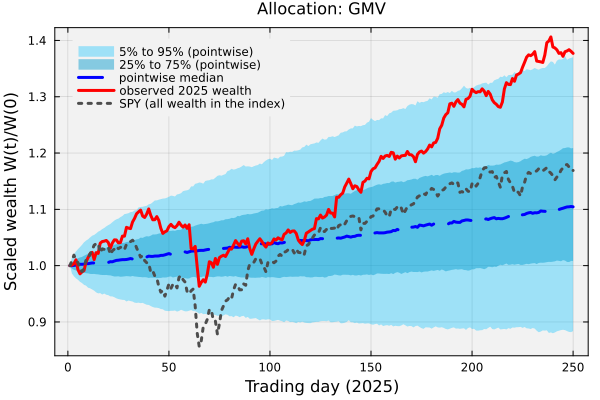

In [17]:
let

    # Compute pointwise quantiles of scaled wealth -
    # For each trading day (row), take quantiles across all paths, then divide by W₀.
    probabilities = [0.05, 0.25, 0.50, 0.75, 0.95]; # quantile probabilities
    Q = scaled_wealth_quantiles(simulated_wealth, W₀, probabilities); # trading day × probability
    q05 = Q[:,1]; # 5th percentile of scaled wealth
    q25 = Q[:,2]; # 25th percentile
    q50 = Q[:,3]; # median
    q75 = Q[:,4]; # 75th percentile
    q95 = Q[:,5]; # 95th percentile
    days = 1:N_2025; # trading-day index, 1 = first trading day of 2025

    # Plot the bands, median, observed wealth, and SPY -
    # fillrange shades between two curves. plot! adds a series to the current plot.
    # Draw the wider band first so the inner band and median remain visible.
    plot(days, q95, fillrange = q05, c = :deepskyblue1, alpha = 0.35, lw = 0, label = "5% to 95% (pointwise)")
    plot!(days, q75, fillrange = q25, c = :deepskyblue3, alpha = 0.45, lw = 0, label = "25% to 75% (pointwise)")
    plot!(days, q50, c = :blue, lw = 3, ls = :dash, label = "pointwise median")
    plot!(days, actual_wealth ./ W₀, c = :red, lw = 3, label = "observed 2025 wealth")
    plot!(days, spy_wealth ./ W₀, c = :gray30, lw = 3, ls = :dot, label = "SPY (all wealth in the index)")

    # Style the plot -
    plot!(xlabel = "Trading day (2025)", ylabel = "Scaled wealth W(t)/W(0)",
        title = "Allocation: $(allocation_case)", titlefontsize = 11,
        bg = "gray95", background_color_outside = "white", framestyle = :box,
        fg_legend = :transparent, legend = :topleft)
end

__What do we see?__ Every curve starts at one, our initial investment. The bands widen through the year as the simulated paths spread apart. In the final weeks of the year, the observed wealth of the default allocation rises above the 95th percentile. On those dates, at most $5\%$ of the simulated paths are worth as much as our portfolio.

How the observed path compares with the bands depends on the chosen allocation and on whether the estimates from 2014 to 2024 still describe 2025. The out-of-sample example in L5a examined the same question for one stock. Change `allocation_case` and rerun to compare the other allocations.

Next, we use each path's final wealth to calculate scaled NPV and estimate the probability of exceeding the trade-rule target.

___

## Task 3: Portfolio NPV and the Trade Rule
In this task, we calculate the scaled net present value of the portfolio at the end of 2025 and estimate the probability that it exceeds a chosen target.

The [L6a lecture](CHEME-5660-L6a-Lecture-MAGBM-Data-Portfolios-Fall-2026.ipynb) applies the L4b trade rule to a whole portfolio. If we sell our shares for $W_T$ dollars after the holding period $T$ from Task 1, the scaled net present value at the benchmark growth rate $g_y$ is given by:
$$
\rho_T=\frac{\operatorname{NPV}(g_y,T)}{W_0}
=\frac{W_T}{W_0}e^{-g_yT}-1.
$$
This is the discounted gain or loss per dollar invested. A positive value means that the portfolio exceeds the benchmark.

__How do we estimate the probability of exceeding a target?__

Each simulated path gives a year-end wealth $W_T$ and a scaled NPV $\rho_T$. We count the paths with $\rho_T>\rho_\star$ and divide by the number of simulated paths, $n$:
$$
\hat p=\frac{\text{number of paths with }\rho_T>\rho_\star}{n}.
$$
A new set of random draws may give a different estimate. We measure this variation with the Monte Carlo standard error:
$$
\operatorname{SE}(\hat p)=\sqrt{\frac{\hat p(1-\hat p)}{n}}.
$$
The standard error treats the fitted model parameters as fixed, so it measures only the variation from using a finite number of paths.

Let's compute the scaled NPV on every simulated path and store it in `ρ_T::Vector{Float64}`, along with the observed value `ρ_T_actual::Float64` from the 2025 wealth:

In [18]:
ρ_T, ρ_T_actual = let

    # Compute the scaled NPV, ρ_T = (W_T/W₀)e^{-g_y T} - 1 -
    # simulated_wealth[end, :] is the last row, the year-end wealth W_T on every path.
    # The dots in ./, .*, and .- apply each operation to every path.
    T = (N_2025 - 1)*Δt; # holding period (years)
    ρ = (simulated_wealth[end, :] ./ W₀) .* exp(-g_y*T) .- 1.0; # one ρ_T per path (dimensionless)
    ρ_actual = (actual_wealth[end]/W₀)*exp(-g_y*T) - 1.0; # observed scaled NPV (dimensionless)
    (ρ, ρ_actual); # the returned tuple unpacks into ρ_T and ρ_T_actual
end;

### Estimate the target probability
Let's tabulate the target probability, its standard error, and the simulated and observed scaled NPV:

In [19]:
let

    # Estimate the target probability and its Monte Carlo standard error -
    n = length(ρ_T); # number of simulated paths
    p̂ = count(ρ_T .> ρ_target)/n; # ρ_T .> ρ_target is a true/false vector, count adds the trues
    se = sqrt(p̂*(1 - p̂)/n); # SE(p̂) = sqrt(p̂(1 - p̂)/n), for fixed model inputs

    # Build the summary table -
    # string(...) turns each value into text, so the count and the decimals share one column.
    # The last row is the fraction of simulated ρ_T below the observed 2025 value.
    df = DataFrame(
        Quantity = [
            "Simulated paths",
            "Target scaled NPV",
            "Probability above target",
            "Monte Carlo standard error",
            "Simulated scaled NPV: 5th percentile",
            "Simulated scaled NPV: median",
            "Simulated scaled NPV: 95th percentile",
            "Observed 2025 scaled NPV",
            "Fraction below observed outcome"
        ],
        Value = [
            string(n),
            string(ρ_target),
            string(round(p̂, digits=3)),
            string(round(se, digits=3)),
            string(round(quantile(ρ_T, 0.05), digits=3)),
            string(round(median(ρ_T), digits=3)),
            string(round(quantile(ρ_T, 0.95), digits=3)),
            string(round(ρ_T_actual, digits=3)),
            string(round(count(ρ_T .< ρ_T_actual)/n, digits=3))
        ]
    );

    # Display the table without the column-type row -
    pretty_table(Matrix(df), backend = :text, alignment = [:l, :r],
        column_labels = ["Quantity", "Value"],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 --------------------------------------- --------
  Quantity                                 Value 
 --------------------------------------- --------
  Simulated paths                           2000
  Target scaled NPV                          0.0
  Probability above target                 0.676
  Monte Carlo standard error                0.01
  Simulated scaled NPV: 5th percentile    -0.151
  Simulated scaled NPV: median             0.061
  Simulated scaled NPV: 95th percentile    0.316
  Observed 2025 scaled NPV                 0.322
  Fraction below observed outcome          0.953
 --------------------------------------- --------


__What do we see?__ With the default allocation and a zero target, about $68\%$ of the simulated portfolios exceed the benchmark at year end, with a standard error of about one percentage point. The median scaled NPV of $0.061$ is a discounted gain of $6.1$ cents per dollar invested, and the middle $90\%$ of simulated outcomes lie between $-0.151$ and $0.316$.

### Compare the simulated and observed outcomes
To see the shape of the distribution, let's plot all the simulated values of $\rho_T$ with [the histogram(...) function](https://docs.juliaplots.org/stable/series_types/histogram/). The vertical axis shows **density**: the bars are scaled so that their total area is one, and the area to the right of the target line approximates $\hat p$. The black dashed line marks the target, and the red line marks the observed 2025 scaled NPV:

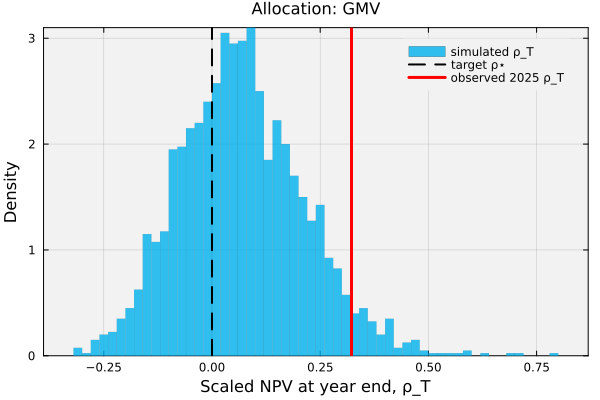

In [20]:
let

    # Plot the distribution of simulated ρ_T -
    # normalize = :pdf scales the bars so their total area is one.
    histogram(ρ_T, bins = 60, normalize = :pdf, c = :deepskyblue2, lw = 0, alpha = 0.8, label = "simulated ρ_T")

    # Mark the target and the observed 2025 value with vertical lines -
    vline!([ρ_target], c = :black, lw = 2, ls = :dash, label = "target ρ⋆")
    vline!([ρ_T_actual], c = :red, lw = 3, label = "observed 2025 ρ_T")

    # Style the plot -
    plot!(xlabel = "Scaled NPV at year end, ρ_T", ylabel = "Density", title = "Allocation: $(allocation_case)", titlefontsize = 11,
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent)
end

__What do we see?__ For the default allocation, the longer right tail shows a few paths with much larger gains. The observed 2025 scaled NPV of $0.322$ lies just beyond the simulated 95th percentile, with about $95.3\%$ of simulated outcomes below it. Under the fitted model, 2025 was an unusually favorable year for this portfolio.

The Task 1 check showed that the simulation reproduces the fitted inputs. Whether those 2014 to 2024 estimates describe 2025 is a question one observed year cannot settle.

___

## Summary
In this example, we estimated mean growth rates and their covariance for a basket of assets, then used a multiple asset GBM model to simulate portfolio wealth and apply the scheduled-sale trade rule.

> __Key Takeaways:__
>
> * **Correlated price simulation:** We estimated mean growth rates and their covariance, constructed the multiple asset GBM model, and checked its simulated growth rates. These checks confirmed that the simulation reproduced the fitted means and covariance to Monte Carlo accuracy.
>
> * **Buy-and-hold portfolio wealth:** We converted initial weights into fixed share counts and added the value of those holdings on each path. Pointwise percentiles described the spread of wealth on each date and let us compare simulated outcomes with the observed portfolio and SPY.
>
> * **Portfolio NPV and target probabilities:** We discounted year-end wealth at the benchmark growth rate and compared it with the initial investment. Counting simulated outcomes above the target gave an estimated probability, and its standard error quantified Monte Carlo uncertainty for fixed model inputs.

These simulations describe outcomes under the fitted model. The [minimum-variance portfolio example](CHEME-5660-L6a-Example-Data-MinVar-Portfolio-Fall-2026.ipynb) develops the optimization step and compares allocations using observed 2025 prices.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___